In [74]:
!pip install unidecode

In [75]:
import pandas as pd
import numpy as np
from IPython.display import display
from unidecode import unidecode
import re
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("Full_Quan_binh-tan.csv", encoding = "utf-8")
display(df)

,Giá,Địa chỉ,Loại hình nhà ở,Diện tích đất,Chiều ngang,Chiều dài,Số phòng ngủ,Số phòng vệ sinh,Tổng số tầng,Giấy tờ pháp lý
0,6 tỷ,"Đường Hương Lộ 2, Phường Bình Trị Đông A, Quận...","Nhà ngõ, hẻm",50 m²,4 m,NaN,6 phòng,6 phòng,NaN,Đã có sổ
1,"5,9 tỷ","Đường Số 2, Phường Bình Hưng Hoà B, Quận Bình ...","Nhà ngõ, hẻm",56 m²,4 m,14 m,5 phòng,5 phòng,3.0,Đã có sổ
2,"4,65 tỷ","Đường Kinh Dương Vương, Phường An Lạc, Quận Bì...","Nhà ngõ, hẻm",64 m²,NaN,NaN,2 phòng,1 phòng,NaN,Đã có sổ
3,"3,1 tỷ","Đường Tỉnh lộ 10, Phường An Lạc, Quận Bình Tân...","Nhà ngõ, hẻm",20 m²,3 m,6 m,3 phòng,2 phòng,3.0,Đã có sổ
4,"6,05 tỷ","Đường 18B, Phường Bình Hưng Hoà A, Quận Bình T...","Nhà ngõ, hẻm",56 m²,4 m,14 m,4 phòng,4 phòng,NaN,Đã có sổ
...,...,...,...,...,...,...,...,...,...,...
11831,"7,3 tỷ","Đường Kinh Dương Vương, Phường An Lạc, Quận Bì...","Nhà mặt phố, mặt tiền",80 m²,5.9 m,13.5 m,5 phòng,5 phòng,5.0,Đã có sổ
11832,"2,9 tỷ","Ngay Kinh Dương Vương, Phường An Lạc, Quận Bìn...","Nhà mặt phố, mặt tiền",31 m²,3.3 m,10 m,2 phòng,NaN,NaN,Đã có sổ
11833,"2,7 tỷ","Đường Nguyễn Thị Tú, Phường Bình Hưng Hoà B, Q...","Nhà ngõ, hẻm",52 m²,NaN,NaN,2 phòng,2 phòng,1.0,Đã có sổ
11834,"5,7 tỷ","Đường số 1, Phường Bình Hưng Hoà A, Quận Bình ...","Nhà ngõ, hẻm",65 m²,4 m,16 m,4 phòng,4 phòng,3.0,Đã có sổ


In [76]:
df.columns = ["price", "address", "house_type", "acreage", "width", "length", "bedrooms", "bathrooms", "floors", "legal_status"]
display(df)

,price,address,house_type,acreage,width,length,bedrooms,bathrooms,floors,legal_status
0,6 tỷ,"Đường Hương Lộ 2, Phường Bình Trị Đông A, Quận...","Nhà ngõ, hẻm",50 m²,4 m,NaN,6 phòng,6 phòng,NaN,Đã có sổ
1,"5,9 tỷ","Đường Số 2, Phường Bình Hưng Hoà B, Quận Bình ...","Nhà ngõ, hẻm",56 m²,4 m,14 m,5 phòng,5 phòng,3.0,Đã có sổ
2,"4,65 tỷ","Đường Kinh Dương Vương, Phường An Lạc, Quận Bì...","Nhà ngõ, hẻm",64 m²,NaN,NaN,2 phòng,1 phòng,NaN,Đã có sổ
3,"3,1 tỷ","Đường Tỉnh lộ 10, Phường An Lạc, Quận Bình Tân...","Nhà ngõ, hẻm",20 m²,3 m,6 m,3 phòng,2 phòng,3.0,Đã có sổ
4,"6,05 tỷ","Đường 18B, Phường Bình Hưng Hoà A, Quận Bình T...","Nhà ngõ, hẻm",56 m²,4 m,14 m,4 phòng,4 phòng,NaN,Đã có sổ
...,...,...,...,...,...,...,...,...,...,...
11831,"7,3 tỷ","Đường Kinh Dương Vương, Phường An Lạc, Quận Bì...","Nhà mặt phố, mặt tiền",80 m²,5.9 m,13.5 m,5 phòng,5 phòng,5.0,Đã có sổ
11832,"2,9 tỷ","Ngay Kinh Dương Vương, Phường An Lạc, Quận Bìn...","Nhà mặt phố, mặt tiền",31 m²,3.3 m,10 m,2 phòng,NaN,NaN,Đã có sổ
11833,"2,7 tỷ","Đường Nguyễn Thị Tú, Phường Bình Hưng Hoà B, Q...","Nhà ngõ, hẻm",52 m²,NaN,NaN,2 phòng,2 phòng,1.0,Đã có sổ
11834,"5,7 tỷ","Đường số 1, Phường Bình Hưng Hoà A, Quận Bình ...","Nhà ngõ, hẻm",65 m²,4 m,16 m,4 phòng,4 phòng,3.0,Đã có sổ


In [77]:
df.dropna(inplace=True)
display(df)

,price,address,house_type,acreage,width,length,bedrooms,bathrooms,floors,legal_status
1,"5,9 tỷ","Đường Số 2, Phường Bình Hưng Hoà B, Quận Bình ...","Nhà ngõ, hẻm",56 m²,4 m,14 m,5 phòng,5 phòng,3.0,Đã có sổ
3,"3,1 tỷ","Đường Tỉnh lộ 10, Phường An Lạc, Quận Bình Tân...","Nhà ngõ, hẻm",20 m²,3 m,6 m,3 phòng,2 phòng,3.0,Đã có sổ
6,"1,98 tỷ","Đường Tên Lửa, Phường Bình Trị Đông B, Quận Bì...","Nhà ngõ, hẻm",30 m²,3 m,10 m,2 phòng,2 phòng,1.0,Đã có sổ
7,"15,9 tỷ","Đường An Dương Vương, Phường An Lạc, Quận Bình...","Nhà mặt phố, mặt tiền",73.4 m²,4 m,26 m,5 phòng,6 phòng,5.0,Đã có sổ
8,"4,1 tỷ","Đường Hương Lộ 3, Phường Bình Hưng Hòa, Quận B...","Nhà ngõ, hẻm",60 m²,8 m,7 m,3 phòng,2 phòng,2.0,Đã có sổ
...,...,...,...,...,...,...,...,...,...,...
11828,3 tỷ,"Đường Hương Lộ 2, Phường Bình Trị Đông A, Quận...","Nhà ngõ, hẻm",40 m²,4 m,10 m,2 phòng,2 phòng,2.0,Đã có sổ
11830,"3,8 tỷ","Đường Hương Lộ 2, Phường Bình Trị Đông A, Quận...","Nhà ngõ, hẻm",48 m²,4 m,12 m,2 phòng,2 phòng,2.0,Đã có sổ
11831,"7,3 tỷ","Đường Kinh Dương Vương, Phường An Lạc, Quận Bì...","Nhà mặt phố, mặt tiền",80 m²,5.9 m,13.5 m,5 phòng,5 phòng,5.0,Đã có sổ
11834,"5,7 tỷ","Đường số 1, Phường Bình Hưng Hoà A, Quận Bình ...","Nhà ngõ, hẻm",65 m²,4 m,16 m,4 phòng,4 phòng,3.0,Đã có sổ


In [78]:
#Unidecode
df["legal_status"] = df["legal_status"].astype(str).apply(lambda x: unidecode(x).strip().lower())
df["house_type"] = df["house_type"].astype(str).apply(lambda x: unidecode(x).strip().lower())
display(df)

,price,address,house_type,acreage,width,length,bedrooms,bathrooms,floors,legal_status
1,"5,9 tỷ","Đường Số 2, Phường Bình Hưng Hoà B, Quận Bình ...","nha ngo, hem",56 m²,4 m,14 m,5 phòng,5 phòng,3.0,da co so
3,"3,1 tỷ","Đường Tỉnh lộ 10, Phường An Lạc, Quận Bình Tân...","nha ngo, hem",20 m²,3 m,6 m,3 phòng,2 phòng,3.0,da co so
6,"1,98 tỷ","Đường Tên Lửa, Phường Bình Trị Đông B, Quận Bì...","nha ngo, hem",30 m²,3 m,10 m,2 phòng,2 phòng,1.0,da co so
7,"15,9 tỷ","Đường An Dương Vương, Phường An Lạc, Quận Bình...","nha mat pho, mat tien",73.4 m²,4 m,26 m,5 phòng,6 phòng,5.0,da co so
8,"4,1 tỷ","Đường Hương Lộ 3, Phường Bình Hưng Hòa, Quận B...","nha ngo, hem",60 m²,8 m,7 m,3 phòng,2 phòng,2.0,da co so
...,...,...,...,...,...,...,...,...,...,...
11828,3 tỷ,"Đường Hương Lộ 2, Phường Bình Trị Đông A, Quận...","nha ngo, hem",40 m²,4 m,10 m,2 phòng,2 phòng,2.0,da co so
11830,"3,8 tỷ","Đường Hương Lộ 2, Phường Bình Trị Đông A, Quận...","nha ngo, hem",48 m²,4 m,12 m,2 phòng,2 phòng,2.0,da co so
11831,"7,3 tỷ","Đường Kinh Dương Vương, Phường An Lạc, Quận Bì...","nha mat pho, mat tien",80 m²,5.9 m,13.5 m,5 phòng,5 phòng,5.0,da co so
11834,"5,7 tỷ","Đường số 1, Phường Bình Hưng Hoà A, Quận Bình ...","nha ngo, hem",65 m²,4 m,16 m,4 phòng,4 phòng,3.0,da co so


In [79]:
def convert_price(value):
    value = value.lower().replace(",", ".").strip()
    try:
        if "tỷ" in value:
            return float(value.replace("tỷ", "").strip())
        elif "triệu" in value:
            return float(value.replace("triệu", "").strip()) / 1000
    except ValueError:
        return None
    return None

#Giá nhà
df['price'] = df['price'].apply(convert_price)
display(df)

,price,address,house_type,acreage,width,length,bedrooms,bathrooms,floors,legal_status
1,5.90,"Đường Số 2, Phường Bình Hưng Hoà B, Quận Bình ...","nha ngo, hem",56 m²,4 m,14 m,5 phòng,5 phòng,3.0,da co so
3,3.10,"Đường Tỉnh lộ 10, Phường An Lạc, Quận Bình Tân...","nha ngo, hem",20 m²,3 m,6 m,3 phòng,2 phòng,3.0,da co so
6,1.98,"Đường Tên Lửa, Phường Bình Trị Đông B, Quận Bì...","nha ngo, hem",30 m²,3 m,10 m,2 phòng,2 phòng,1.0,da co so
7,15.90,"Đường An Dương Vương, Phường An Lạc, Quận Bình...","nha mat pho, mat tien",73.4 m²,4 m,26 m,5 phòng,6 phòng,5.0,da co so
8,4.10,"Đường Hương Lộ 3, Phường Bình Hưng Hòa, Quận B...","nha ngo, hem",60 m²,8 m,7 m,3 phòng,2 phòng,2.0,da co so
...,...,...,...,...,...,...,...,...,...,...
11828,3.00,"Đường Hương Lộ 2, Phường Bình Trị Đông A, Quận...","nha ngo, hem",40 m²,4 m,10 m,2 phòng,2 phòng,2.0,da co so
11830,3.80,"Đường Hương Lộ 2, Phường Bình Trị Đông A, Quận...","nha ngo, hem",48 m²,4 m,12 m,2 phòng,2 phòng,2.0,da co so
11831,7.30,"Đường Kinh Dương Vương, Phường An Lạc, Quận Bì...","nha mat pho, mat tien",80 m²,5.9 m,13.5 m,5 phòng,5 phòng,5.0,da co so
11834,5.70,"Đường số 1, Phường Bình Hưng Hoà A, Quận Bình ...","nha ngo, hem",65 m²,4 m,16 m,4 phòng,4 phòng,3.0,da co so


In [80]:
df['width'] = df['width'].str.extract(r'([\d.]+)').astype(float).round(2)
df['length'] = df['length'].str.extract(r'([\d.]+)').astype(float).round(2)
display(df)

,price,address,house_type,acreage,width,length,bedrooms,bathrooms,floors,legal_status
1,5.90,"Đường Số 2, Phường Bình Hưng Hoà B, Quận Bình ...","nha ngo, hem",56 m²,4.0,14.0,5 phòng,5 phòng,3.0,da co so
3,3.10,"Đường Tỉnh lộ 10, Phường An Lạc, Quận Bình Tân...","nha ngo, hem",20 m²,3.0,6.0,3 phòng,2 phòng,3.0,da co so
6,1.98,"Đường Tên Lửa, Phường Bình Trị Đông B, Quận Bì...","nha ngo, hem",30 m²,3.0,10.0,2 phòng,2 phòng,1.0,da co so
7,15.90,"Đường An Dương Vương, Phường An Lạc, Quận Bình...","nha mat pho, mat tien",73.4 m²,4.0,26.0,5 phòng,6 phòng,5.0,da co so
8,4.10,"Đường Hương Lộ 3, Phường Bình Hưng Hòa, Quận B...","nha ngo, hem",60 m²,8.0,7.0,3 phòng,2 phòng,2.0,da co so
...,...,...,...,...,...,...,...,...,...,...
11828,3.00,"Đường Hương Lộ 2, Phường Bình Trị Đông A, Quận...","nha ngo, hem",40 m²,4.0,10.0,2 phòng,2 phòng,2.0,da co so
11830,3.80,"Đường Hương Lộ 2, Phường Bình Trị Đông A, Quận...","nha ngo, hem",48 m²,4.0,12.0,2 phòng,2 phòng,2.0,da co so
11831,7.30,"Đường Kinh Dương Vương, Phường An Lạc, Quận Bì...","nha mat pho, mat tien",80 m²,5.9,13.5,5 phòng,5 phòng,5.0,da co so
11834,5.70,"Đường số 1, Phường Bình Hưng Hoà A, Quận Bình ...","nha ngo, hem",65 m²,4.0,16.0,4 phòng,4 phòng,3.0,da co so


In [81]:
#Diện tích
df['acreage'] = (df['width']*df['length']).round(2)
display(df)

,price,address,house_type,acreage,width,length,bedrooms,bathrooms,floors,legal_status
1,5.90,"Đường Số 2, Phường Bình Hưng Hoà B, Quận Bình ...","nha ngo, hem",56.00,4.0,14.0,5 phòng,5 phòng,3.0,da co so
3,3.10,"Đường Tỉnh lộ 10, Phường An Lạc, Quận Bình Tân...","nha ngo, hem",18.00,3.0,6.0,3 phòng,2 phòng,3.0,da co so
6,1.98,"Đường Tên Lửa, Phường Bình Trị Đông B, Quận Bì...","nha ngo, hem",30.00,3.0,10.0,2 phòng,2 phòng,1.0,da co so
7,15.90,"Đường An Dương Vương, Phường An Lạc, Quận Bình...","nha mat pho, mat tien",104.00,4.0,26.0,5 phòng,6 phòng,5.0,da co so
8,4.10,"Đường Hương Lộ 3, Phường Bình Hưng Hòa, Quận B...","nha ngo, hem",56.00,8.0,7.0,3 phòng,2 phòng,2.0,da co so
...,...,...,...,...,...,...,...,...,...,...
11828,3.00,"Đường Hương Lộ 2, Phường Bình Trị Đông A, Quận...","nha ngo, hem",40.00,4.0,10.0,2 phòng,2 phòng,2.0,da co so
11830,3.80,"Đường Hương Lộ 2, Phường Bình Trị Đông A, Quận...","nha ngo, hem",48.00,4.0,12.0,2 phòng,2 phòng,2.0,da co so
11831,7.30,"Đường Kinh Dương Vương, Phường An Lạc, Quận Bì...","nha mat pho, mat tien",79.65,5.9,13.5,5 phòng,5 phòng,5.0,da co so
11834,5.70,"Đường số 1, Phường Bình Hưng Hoà A, Quận Bình ...","nha ngo, hem",64.00,4.0,16.0,4 phòng,4 phòng,3.0,da co so


In [82]:
#Phòng ngủ
df['bedrooms'] = df['bedrooms'].replace('nhiều hơn 10 phòng', '11')
df['bedrooms'] = df['bedrooms'].str.extract(r'(\d+)').astype(int)
df['bathrooms'] = df['bathrooms'].replace('Nhiều hơn 6 phòng', '7')
df['bathrooms'] = df['bathrooms'].str.extract(r'(\d+)').astype(int)
display(df)

,price,address,house_type,acreage,width,length,bedrooms,bathrooms,floors,legal_status
1,5.90,"Đường Số 2, Phường Bình Hưng Hoà B, Quận Bình ...","nha ngo, hem",56.00,4.0,14.0,5,5,3.0,da co so
3,3.10,"Đường Tỉnh lộ 10, Phường An Lạc, Quận Bình Tân...","nha ngo, hem",18.00,3.0,6.0,3,2,3.0,da co so
6,1.98,"Đường Tên Lửa, Phường Bình Trị Đông B, Quận Bì...","nha ngo, hem",30.00,3.0,10.0,2,2,1.0,da co so
7,15.90,"Đường An Dương Vương, Phường An Lạc, Quận Bình...","nha mat pho, mat tien",104.00,4.0,26.0,5,6,5.0,da co so
8,4.10,"Đường Hương Lộ 3, Phường Bình Hưng Hòa, Quận B...","nha ngo, hem",56.00,8.0,7.0,3,2,2.0,da co so
...,...,...,...,...,...,...,...,...,...,...
11828,3.00,"Đường Hương Lộ 2, Phường Bình Trị Đông A, Quận...","nha ngo, hem",40.00,4.0,10.0,2,2,2.0,da co so
11830,3.80,"Đường Hương Lộ 2, Phường Bình Trị Đông A, Quận...","nha ngo, hem",48.00,4.0,12.0,2,2,2.0,da co so
11831,7.30,"Đường Kinh Dương Vương, Phường An Lạc, Quận Bì...","nha mat pho, mat tien",79.65,5.9,13.5,5,5,5.0,da co so
11834,5.70,"Đường số 1, Phường Bình Hưng Hoà A, Quận Bình ...","nha ngo, hem",64.00,4.0,16.0,4,4,3.0,da co so


In [83]:
#Số tầng
df['floors'] = df['floors'].astype(int)
display(df)

,price,address,house_type,acreage,width,length,bedrooms,bathrooms,floors,legal_status
1,5.90,"Đường Số 2, Phường Bình Hưng Hoà B, Quận Bình ...","nha ngo, hem",56.00,4.0,14.0,5,5,3,da co so
3,3.10,"Đường Tỉnh lộ 10, Phường An Lạc, Quận Bình Tân...","nha ngo, hem",18.00,3.0,6.0,3,2,3,da co so
6,1.98,"Đường Tên Lửa, Phường Bình Trị Đông B, Quận Bì...","nha ngo, hem",30.00,3.0,10.0,2,2,1,da co so
7,15.90,"Đường An Dương Vương, Phường An Lạc, Quận Bình...","nha mat pho, mat tien",104.00,4.0,26.0,5,6,5,da co so
8,4.10,"Đường Hương Lộ 3, Phường Bình Hưng Hòa, Quận B...","nha ngo, hem",56.00,8.0,7.0,3,2,2,da co so
...,...,...,...,...,...,...,...,...,...,...
11828,3.00,"Đường Hương Lộ 2, Phường Bình Trị Đông A, Quận...","nha ngo, hem",40.00,4.0,10.0,2,2,2,da co so
11830,3.80,"Đường Hương Lộ 2, Phường Bình Trị Đông A, Quận...","nha ngo, hem",48.00,4.0,12.0,2,2,2,da co so
11831,7.30,"Đường Kinh Dương Vương, Phường An Lạc, Quận Bì...","nha mat pho, mat tien",79.65,5.9,13.5,5,5,5,da co so
11834,5.70,"Đường số 1, Phường Bình Hưng Hoà A, Quận Bình ...","nha ngo, hem",64.00,4.0,16.0,4,4,3,da co so


In [84]:
# Tách Đường, Phường, Quận, Thành Phố
df[['street', 'ward', 'district', 'city']] = df['address'].str.rsplit(',', n=3, expand=True)
# Chuẩn hóa dữ liệu: loại bỏ dấu và chuyển thường
for col in ['street', 'ward', 'district', 'city']:
    df[col] = df[col].astype(str).apply(lambda x: unidecode(x).strip().lower())

df = df.drop(columns=['address'])
display(df)

,price,house_type,acreage,width,length,bedrooms,bathrooms,floors,legal_status,street,ward,district,city
1,5.90,"nha ngo, hem",56.00,4.0,14.0,5,5,3,da co so,duong so 2,phuong binh hung hoa b,quan binh tan,tp ho chi minh
3,3.10,"nha ngo, hem",18.00,3.0,6.0,3,2,3,da co so,duong tinh lo 10,phuong an lac,quan binh tan,tp ho chi minh
6,1.98,"nha ngo, hem",30.00,3.0,10.0,2,2,1,da co so,duong ten lua,phuong binh tri dong b,quan binh tan,tp ho chi minh
7,15.90,"nha mat pho, mat tien",104.00,4.0,26.0,5,6,5,da co so,duong an duong vuong,phuong an lac,quan binh tan,tp ho chi minh
8,4.10,"nha ngo, hem",56.00,8.0,7.0,3,2,2,da co so,duong huong lo 3,phuong binh hung hoa,quan binh tan,tp ho chi minh
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11828,3.00,"nha ngo, hem",40.00,4.0,10.0,2,2,2,da co so,duong huong lo 2,phuong binh tri dong a,quan binh tan,tp ho chi minh
11830,3.80,"nha ngo, hem",48.00,4.0,12.0,2,2,2,da co so,duong huong lo 2,phuong binh tri dong a,quan binh tan,tp ho chi minh
11831,7.30,"nha mat pho, mat tien",79.65,5.9,13.5,5,5,5,da co so,duong kinh duong vuong,phuong an lac,quan binh tan,tp ho chi minh
11834,5.70,"nha ngo, hem",64.00,4.0,16.0,4,4,3,da co so,duong so 1,phuong binh hung hoa a,quan binh tan,tp ho chi minh


In [85]:
# Hàm trích tên đường
def extract_ten_duong(diachi):
    # Nếu có từ 'duong' thì lấy từ sau nó
    match = re.search(r'duong\s+([a-z0-9\s\-]+)', diachi)
    if match:
        return match.group(1).strip()
    # Nếu không có, lấy cụm chữ cái đầu tiên (bỏ số nhà)
    match = re.search(r'^[0-9\-\/]*\s*([a-z\s\-]+?),', diachi)
    if match:
        return match.group(1).strip()
    return None

# Áp dụng hàm trích xuất
df['street'] = df['street'].apply(extract_ten_duong).apply(lambda x: "duong " + x if isinstance(x, str) else x)
display(df)

,price,house_type,acreage,width,length,bedrooms,bathrooms,floors,legal_status,street,ward,district,city
1,5.90,"nha ngo, hem",56.00,4.0,14.0,5,5,3,da co so,duong so 2,phuong binh hung hoa b,quan binh tan,tp ho chi minh
3,3.10,"nha ngo, hem",18.00,3.0,6.0,3,2,3,da co so,duong tinh lo 10,phuong an lac,quan binh tan,tp ho chi minh
6,1.98,"nha ngo, hem",30.00,3.0,10.0,2,2,1,da co so,duong ten lua,phuong binh tri dong b,quan binh tan,tp ho chi minh
7,15.90,"nha mat pho, mat tien",104.00,4.0,26.0,5,6,5,da co so,duong an duong vuong,phuong an lac,quan binh tan,tp ho chi minh
8,4.10,"nha ngo, hem",56.00,8.0,7.0,3,2,2,da co so,duong huong lo 3,phuong binh hung hoa,quan binh tan,tp ho chi minh
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11828,3.00,"nha ngo, hem",40.00,4.0,10.0,2,2,2,da co so,duong huong lo 2,phuong binh tri dong a,quan binh tan,tp ho chi minh
11830,3.80,"nha ngo, hem",48.00,4.0,12.0,2,2,2,da co so,duong huong lo 2,phuong binh tri dong a,quan binh tan,tp ho chi minh
11831,7.30,"nha mat pho, mat tien",79.65,5.9,13.5,5,5,5,da co so,duong kinh duong vuong,phuong an lac,quan binh tan,tp ho chi minh
11834,5.70,"nha ngo, hem",64.00,4.0,16.0,4,4,3,da co so,duong so 1,phuong binh hung hoa a,quan binh tan,tp ho chi minh


In [86]:
df.replace(["", " ", "null", "None"], np.nan, inplace=True)
df = df.dropna()
display(df)

,price,house_type,acreage,width,length,bedrooms,bathrooms,floors,legal_status,street,ward,district,city
1,5.90,"nha ngo, hem",56.00,4.0,14.0,5,5,3,da co so,duong so 2,phuong binh hung hoa b,quan binh tan,tp ho chi minh
3,3.10,"nha ngo, hem",18.00,3.0,6.0,3,2,3,da co so,duong tinh lo 10,phuong an lac,quan binh tan,tp ho chi minh
6,1.98,"nha ngo, hem",30.00,3.0,10.0,2,2,1,da co so,duong ten lua,phuong binh tri dong b,quan binh tan,tp ho chi minh
7,15.90,"nha mat pho, mat tien",104.00,4.0,26.0,5,6,5,da co so,duong an duong vuong,phuong an lac,quan binh tan,tp ho chi minh
8,4.10,"nha ngo, hem",56.00,8.0,7.0,3,2,2,da co so,duong huong lo 3,phuong binh hung hoa,quan binh tan,tp ho chi minh
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11828,3.00,"nha ngo, hem",40.00,4.0,10.0,2,2,2,da co so,duong huong lo 2,phuong binh tri dong a,quan binh tan,tp ho chi minh
11830,3.80,"nha ngo, hem",48.00,4.0,12.0,2,2,2,da co so,duong huong lo 2,phuong binh tri dong a,quan binh tan,tp ho chi minh
11831,7.30,"nha mat pho, mat tien",79.65,5.9,13.5,5,5,5,da co so,duong kinh duong vuong,phuong an lac,quan binh tan,tp ho chi minh
11834,5.70,"nha ngo, hem",64.00,4.0,16.0,4,4,3,da co so,duong so 1,phuong binh hung hoa a,quan binh tan,tp ho chi minh


In [87]:
ten_duong = [
    "duong an duong vuong", "duong ao doi", "duong ao sen", "duong ap chien luoc", "duong ba hom", "duong ben loi", "duong bia truyen thong","duong binh hanh", "duong binh long", "duong binh thanh", "duong binh tri dong", "duong bo song", "duong bo tuyen", "duong bong sen","duong bui duong lich", "duong bui huu dien", "duong bui tu toan", "duong cao toc trung luong", "duong cau kinh", "duong cay cam", "duong chien luoc", "duong cong hop", "duong dai lo dong tay", "duong dat moi", "duong dinh nghi xuan", "duong dinh tan khai", "duong do bi", "duong do nang te",
    "duong doan phu tu", "duong 14e", "duong 26 thang 3", "duong a5", "duong a6", "duong duong ba cung", "duong doi", "duong g1", "duong g7", "duong kenh c", "duong m1", "duong sinco", "duong so 1", "duong so 1a","duong so 1b", "duong so 1c", "duong so 1d", "duong so 2", "duong so 2a", "duong so 2b", "duong so 2c","duong so 2d", "duong so 3", "duong so 3a", "duong so 3b", "duong so 3c", "duong so 4", "duong so 4a",
    "duong so 4c", "duong so 5", "duong so 5a", "duong so 5b", "duong so 5c", "duong so 5d", "duong so 5e","duong so 5f", "duong so 6", "duong so 6a", "duong so 7", "duong so 7a", "duong so 7b", "duong so 8","duong so 8b", "duong so 9", "duong so 9a", "duong so 9b", "duong so 10", "duong so 11", "duong so 11a","duong so 12", "duong so 12a", "duong so 13", "duong so 13a", "duong so 13c", "duong so 14", "duong so 14a",
    "duong so 14b", "duong so 15", "duong so 16", "duong so 16a", "duong so 16b", "duong so 17", "duong so 17a","duong so 17b", "duong so 18", "duong so 18a", "duong so 18b", "duong so 18c", "duong so 18d", "duong so 18e","duong so 19", "duong so 19a", "duong so 19b", "duong so 19e", "duong so 20", "duong so 21", "duong so 21a", "duong so 21d", "duong so 22", "duong so 23", "duong so 24", "duong so 24a", "duong so 24b", "duong so 25",
    "duong so 25a", "duong so 26", "duong so 27", "duong so 28", "duong so 29", "duong so 30", "duong so 32","duong so 33b", "duong so 34", "duong so 36", "duong so 38", "duong so 39", "duong so 40", "duong so 40a","duong so 40b", "duong so 42", "duong so 42a", "duong so 43", "duong so 44", "duong so 46", "duong so 46a","duong so 47", "duong so 47c", "duong so 48", "duong so 48a", "duong so 48b", "duong so 49", "duong so 49a",
    "duong so 49b", "duong so 49c", "duong so 50", "duong so 50a", "duong so 50b", "duong so 50c", "duong so 50d","duong so 51", "duong so 52", "duong so 52a", "duong so 52b", "duong so 53", "duong so 532", "duong so 53a","duong so 53c", "duong so 53d", "duong so 54", "duong so 54a", "duong so 55", "duong so 55a", "duong so 57","duong so 57a", "duong so 57b", "duong so 57c", "duong so 59d", "duong trung tam", "duong duong tu quan", "duong go xoai",
    "duong ho hoc lam", "duong ho van long", "duong hoang hung", "duong hoang van hop", "duong hung vuong", "duong huong lo 13", "duong huong lo 2","duong huong lo 3", "duong huong lo 5", "duong huong lo 80", "duong kenh nuoc den", "duong khieu nang tinh", "duong khu y te ky thuat cao", "duong kinh duong vuong",
    "duong lam hoanh", "duong le co", "duong le cong phep", "duong le dinh can", "duong le dinh duong", "duong le loi", "duong le ngung","duong le tan be", "duong le thuc hoach", "duong le trong tan", "duong le van que", "duong le van quoi", "duong lien khu 10-11", "duong lien khu 1-6",
    "duong lien khu 16-18", "duong lien khu 2-10", "duong lien khu 2-5", "duong lien khu 4-5", "duong lien khu 5", "duong lien khu 5-11-12", "duong lien khu 5-6", "duong lien khu 7-13", "duong lien khu 8-9", "duong lo te", "duong lo tu", "duong ly chieu hoang", "duong ly thanh tong", "duong ma lo",
    "duong mieu binh dong", "duong mieu go xoai", "duong nghi xuan", "duong ngo y linh", "duong nguyen cuu phu", "duong nguyen dinh kien", "duong nguyen hoi","duong nguyen huu canh", "duong nguyen quy yem", "duong nguyen son", "duong nguyen thi tu", "duong nguyen thuc duong", "duong nguyen thuc tu", "duong nguyen trieu luat",
    "duong nguyen trong chi", "duong nguyen trong tri", "duong nguyen van cu", "duong pham banh", "duong pham dang giang", "duong phan anh", "duong phan cat tuu","duong phan dinh thong", "duong phan van nam", "duong phung ta chu", "duong quoc lo 1a", "duong song suoi", "duong song tac", "duong ta my duat",
    "duong ta quang buu", "duong tan hoa dong", "duong tan khai", "duong tan ky tan quy", "duong tan son nhi", "duong tan tao", "duong tay lan","duong ten lua", "duong thach lam", "duong thang long", "duong thoai ngoc hau", "duong tinh lo 10", "duong tinh lo 13", "duong tinh lo 8",
    "duong tran dai nghia", "duong tran thanh mai", "duong tran thanh mai", "duong truong phuoc phan", "duong vanh dai trong", "duong vinh loc", "duong vinh loc b","duong vo van kiet", "duong vo van van", "duong vu huu", "duong vuong van huong", "duong xa lo dai han"
]

df = df[df['street'].isin(ten_duong)]
display(df)

,price,house_type,acreage,width,length,bedrooms,bathrooms,floors,legal_status,street,ward,district,city
1,5.90,"nha ngo, hem",56.00,4.0,14.0,5,5,3,da co so,duong so 2,phuong binh hung hoa b,quan binh tan,tp ho chi minh
3,3.10,"nha ngo, hem",18.00,3.0,6.0,3,2,3,da co so,duong tinh lo 10,phuong an lac,quan binh tan,tp ho chi minh
6,1.98,"nha ngo, hem",30.00,3.0,10.0,2,2,1,da co so,duong ten lua,phuong binh tri dong b,quan binh tan,tp ho chi minh
7,15.90,"nha mat pho, mat tien",104.00,4.0,26.0,5,6,5,da co so,duong an duong vuong,phuong an lac,quan binh tan,tp ho chi minh
8,4.10,"nha ngo, hem",56.00,8.0,7.0,3,2,2,da co so,duong huong lo 3,phuong binh hung hoa,quan binh tan,tp ho chi minh
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11828,3.00,"nha ngo, hem",40.00,4.0,10.0,2,2,2,da co so,duong huong lo 2,phuong binh tri dong a,quan binh tan,tp ho chi minh
11830,3.80,"nha ngo, hem",48.00,4.0,12.0,2,2,2,da co so,duong huong lo 2,phuong binh tri dong a,quan binh tan,tp ho chi minh
11831,7.30,"nha mat pho, mat tien",79.65,5.9,13.5,5,5,5,da co so,duong kinh duong vuong,phuong an lac,quan binh tan,tp ho chi minh
11834,5.70,"nha ngo, hem",64.00,4.0,16.0,4,4,3,da co so,duong so 1,phuong binh hung hoa a,quan binh tan,tp ho chi minh


In [88]:
df.describe()


,price,acreage,width,length,bedrooms,bathrooms,floors
count,6128.000000,6128.000000,6128.000000,6128.000000,6128.000000,6128.000000,6128.000000
mean,6.042584,67.870281,4.512945,14.522737,3.417265,3.136913,3.008322
std,6.260222,57.701942,2.028652,5.649681,1.591661,1.440973,8.807283
min,0.670000,4.200000,1.000000,1.050000,1.000000,1.000000,1.000000
25%,3.800000,46.200000,4.000000,11.000000,2.000000,2.000000,2.000000
50%,4.950000,60.000000,4.000000,14.000000,3.000000,3.000000,3.000000
75%,6.490000,75.000000,4.500000,17.000000,4.000000,4.000000,4.000000
max,214.000000,1485.000000,52.000000,112.000000,11.000000,7.000000,450.000000


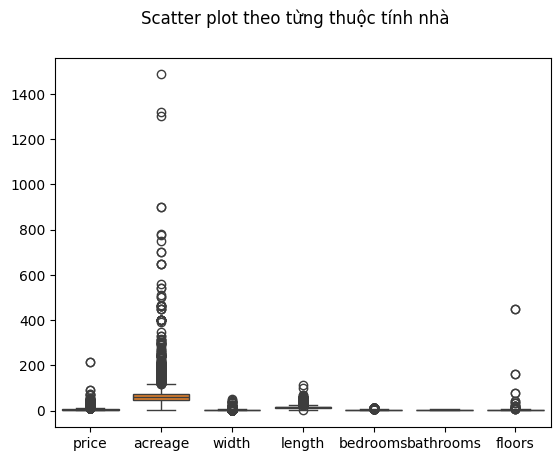

In [89]:
sns.boxplot(df)
plt.suptitle('Scatter plot theo từng thuộc tính nhà')
plt.show()

In [90]:
# Tách giá trị hiếm biệt thự
df = df[df['house_type'] != 'nha biet thu']

In [91]:
def remove_outliers(df, columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 5 * IQR
        upper_bound = Q3 + 5 * IQR
        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    return df
# Xóa outlies
numeric_columns = ['price','width', 'length', 'floors']
df = remove_outliers(df, numeric_columns)

display(df)

,price,house_type,acreage,width,length,bedrooms,bathrooms,floors,legal_status,street,ward,district,city
1,5.90,"nha ngo, hem",56.0,4.0,14.0,5,5,3,da co so,duong so 2,phuong binh hung hoa b,quan binh tan,tp ho chi minh
3,3.10,"nha ngo, hem",18.0,3.0,6.0,3,2,3,da co so,duong tinh lo 10,phuong an lac,quan binh tan,tp ho chi minh
6,1.98,"nha ngo, hem",30.0,3.0,10.0,2,2,1,da co so,duong ten lua,phuong binh tri dong b,quan binh tan,tp ho chi minh
7,15.90,"nha mat pho, mat tien",104.0,4.0,26.0,5,6,5,da co so,duong an duong vuong,phuong an lac,quan binh tan,tp ho chi minh
10,6.39,"nha mat pho, mat tien",66.0,4.0,16.5,4,4,3,da co so,duong so 20,phuong binh hung hoa a,quan binh tan,tp ho chi minh
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11818,5.55,"nha ngo, hem",48.0,4.0,12.0,5,5,4,da co so,duong go xoai,phuong binh hung hoa a,quan binh tan,tp ho chi minh
11828,3.00,"nha ngo, hem",40.0,4.0,10.0,2,2,2,da co so,duong huong lo 2,phuong binh tri dong a,quan binh tan,tp ho chi minh
11830,3.80,"nha ngo, hem",48.0,4.0,12.0,2,2,2,da co so,duong huong lo 2,phuong binh tri dong a,quan binh tan,tp ho chi minh
11834,5.70,"nha ngo, hem",64.0,4.0,16.0,4,4,3,da co so,duong so 1,phuong binh hung hoa a,quan binh tan,tp ho chi minh


In [92]:
df=df.drop_duplicates()

In [93]:
df.describe()

,price,acreage,width,length,bedrooms,bathrooms,floors
count,3410.000000,3410.000000,3410.000000,3410.000000,3410.000000,3410.000000,3410.000000
mean,5.283901,58.999619,4.120109,14.192305,3.318182,3.078886,2.773607
std,2.411798,21.505786,0.487782,4.515688,1.401898,1.370153,1.156971
min,0.670000,4.200000,2.600000,1.050000,1.000000,1.000000,1.000000
25%,3.780000,44.000000,4.000000,11.000000,2.000000,2.000000,2.000000
50%,4.850000,57.570000,4.000000,14.000000,3.000000,3.000000,3.000000
75%,6.150000,72.000000,4.100000,17.000000,4.000000,4.000000,4.000000
max,19.000000,210.000000,5.700000,42.000000,11.000000,7.000000,12.000000


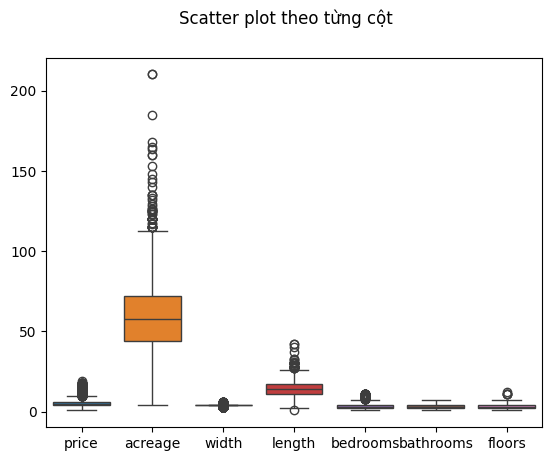

In [94]:
sns.boxplot(df)
plt.suptitle('Scatter plot theo từng cột')
plt.show()

In [95]:
#Xuất ra file clean
df.to_csv('Clean_Quan_BinhTan.csv', encoding="utf-8-sig", header= True, index = None)